# Synthesis: Thesis-Ready RQ Conclusion Matrix

## Objective
Integrate RQ1-RQ3 evidence into a single claim ledger with explicit effect sizes, uncertainty context, and decision status.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.notebook_reporting import canon_graph_set, optional_csv, relative_change, require_csv

ARTIFACT_ROOT = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
sns.set_theme(style='whitegrid', context='talk')

In [2]:
results = require_csv('rq_runner/results.csv', required_columns=('rq', 'aggregation', 'graph_set', 'model', 'test_wmape')).to_pandas()
results['graph_set'] = results['graph_set'].apply(canon_graph_set)
graph_only = results[results['model'] == 'graph_propagation'].copy()

robustness = optional_csv('train_eval_3h/station_robustness_statistics.csv', required_columns=('cohort', 'model', 'paired_sign_permutation_pvalue'))
milestone_best = optional_csv('stgnn_milestones/milestone_best_by_milestone.csv', required_columns=('milestone', 'aggregation', 'test_wmape'))

provenance = pd.DataFrame([
    {'artifact': 'rq_runner/results.csv', 'exists': (ARTIFACT_ROOT / 'rq_runner' / 'results.csv').exists()},
    {'artifact': 'train_eval_3h/station_robustness_statistics.csv', 'exists': (ARTIFACT_ROOT / 'train_eval_3h' / 'station_robustness_statistics.csv').exists()},
    {'artifact': 'stgnn_milestones/milestone_best_by_milestone.csv', 'exists': (ARTIFACT_ROOT / 'stgnn_milestones' / 'milestone_best_by_milestone.csv').exists()},
])

provenance

,artifact,exists
0,rq_runner/results.csv,True
1,train_eval_3h/station_robustness_statistics.csv,True
2,stgnn_milestones/milestone_best_by_milestone.csv,True


In [3]:
def min_wmape(frame: pd.DataFrame, graph_set: str) -> float:
    match = frame[frame['graph_set'] == graph_set]
    return float(match['test_wmape'].min()) if not match.empty else np.nan

rq1 = graph_only[(graph_only['rq'] == 'RQ1') & (graph_only['aggregation'] == 'station')]
rq2 = graph_only[(graph_only['rq'] == 'RQ2') & (graph_only['aggregation'] == 'station')]
rq3 = graph_only[graph_only['rq'] == 'RQ3']

rq1_sd = min_wmape(rq1, 'SD')
rq1_func = np.nanmin([min_wmape(rq1, 'DE'), min_wmape(rq1, 'DC'), min_wmape(rq1, 'DE+DC')])
rq2_all = min_wmape(rq2, 'SD+DE+DC+ATD')
rq2_two = rq2[rq2['graph_set'].str.count(r'\+') == 1]['test_wmape'].min() if not rq2.empty else np.nan
rq3_station = rq3[rq3['aggregation'] == 'station']['test_wmape'].min() if not rq3.empty else np.nan
rq3_community = rq3[rq3['aggregation'] == 'community']['test_wmape'].min() if not rq3.empty else np.nan

conclusion_matrix = pd.DataFrame([
    {'rq': 'RQ1', 'claim': 'Functional graphs outperform SD', 'effect_absolute': rq1_func - rq1_sd if np.isfinite(rq1_func) and np.isfinite(rq1_sd) else np.nan, 'effect_relative': relative_change(rq1_func, rq1_sd) if np.isfinite(rq1_func) and np.isfinite(rq1_sd) else np.nan},
    {'rq': 'RQ2', 'claim': 'All-view fusion improves over best two-view', 'effect_absolute': rq2_all - rq2_two if np.isfinite(rq2_all) and np.isfinite(rq2_two) else np.nan, 'effect_relative': relative_change(rq2_all, rq2_two) if np.isfinite(rq2_all) and np.isfinite(rq2_two) else np.nan},
    {'rq': 'RQ3', 'claim': 'Community aggregation changes sparse-suburban behavior', 'effect_absolute': rq3_community - rq3_station if np.isfinite(rq3_community) and np.isfinite(rq3_station) else np.nan, 'effect_relative': relative_change(rq3_community, rq3_station) if np.isfinite(rq3_community) and np.isfinite(rq3_station) else np.nan},
])

conclusion_matrix

,rq,claim,effect_absolute,effect_relative
0,RQ1,Functional graphs outperform SD,-0.030440,-0.037296
1,RQ2,All-view fusion improves over best two-view,0.013228,0.016711
2,RQ3,Community aggregation changes sparse-suburban ...,-0.508409,-0.633932


In [4]:
uncertainty_rows = []
if robustness is not None:
    robust_df = robustness.to_pandas()
    uncertainty_rows.append({
        'source': 'train_eval robustness',
        'statistic': 'p-value range',
        'value': f"[{robust_df['paired_sign_permutation_pvalue'].min():.4f}, {robust_df['paired_sign_permutation_pvalue'].max():.4f}]"
    })

if milestone_best is not None:
    mdf = milestone_best.to_pandas()
    uncertainty_rows.append({
        'source': 'stgnn milestones',
        'statistic': 'best rows count',
        'value': str(len(mdf)),
    })

uncertainty_ledger = pd.DataFrame(uncertainty_rows)
uncertainty_ledger

,source,statistic,value
0,train_eval robustness,p-value range,"[0.0025, 1.0000]"
1,stgnn milestones,best rows count,2


C:\Users\stefa\AppData\Local\Temp\ipykernel_36592\2434894138.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=viz_df, x='rq', y='effect_relative', palette='crest')


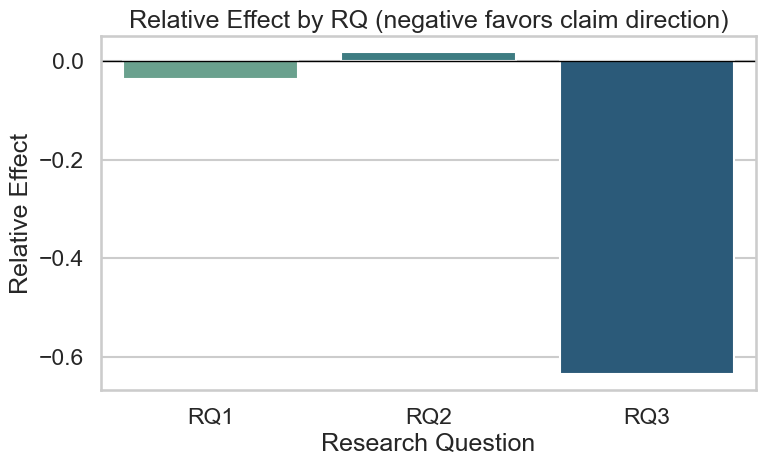

In [5]:
viz_df = conclusion_matrix.dropna(subset=['effect_relative']).copy()

if viz_df.empty:
    print('No finite effect_relative values available for synthesis plot.')
else:
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=viz_df, x='rq', y='effect_relative', palette='crest')
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_title('Relative Effect by RQ (negative favors claim direction)')
    ax.set_ylabel('Relative Effect')
    ax.set_xlabel('Research Question')
    plt.tight_layout()
    plt.show()

## Threats To Validity

- External validity is bounded by Helsinki-Espoo context and current temporal split regime.
- Synthesis consistency depends on artifact freshness; stale outputs can cause claim drift.
- Cross-RQ comparability assumes aligned metric definitions and equivalent preprocessing settings.

In [6]:
def claim_status(effect: float) -> str:
    if not np.isfinite(effect):
        return 'insufficient_data'
    return 'supported' if effect < 0 else 'mixed_or_not_supported'

decision_table = conclusion_matrix.copy()
decision_table['claim_status'] = decision_table['effect_absolute'].apply(claim_status)
decision_table['rationale'] = decision_table['effect_absolute'].apply(lambda x: f'effect_absolute={x:.6f}' if np.isfinite(x) else 'missing effect estimate')

publication_ready = bool((decision_table['claim_status'] != 'insufficient_data').all())

decision_table, pd.DataFrame([{'publication_ready': publication_ready, 'n_claims': len(decision_table)}])

(    rq                                              claim  effect_absolute  \
 0  RQ1                    Functional graphs outperform SD        -0.030440   
 1  RQ2        All-view fusion improves over best two-view         0.013228   
 2  RQ3  Community aggregation changes sparse-suburban ...        -0.508409   
 
    effect_relative            claim_status                  rationale  
 0        -0.037296               supported  effect_absolute=-0.030440  
 1         0.016711  mixed_or_not_supported   effect_absolute=0.013228  
 2        -0.633932               supported  effect_absolute=-0.508409  ,
    publication_ready  n_claims
 0               True         3)